# 04 XGBoost Training

Train and evaluate XGBoost with 5-fold CV for comparison against LightGBM.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from amex_default.config import PLOTS_DIR, REPORTS_DIR
from amex_default.data import get_feature_columns, load_train_features, split_features_target
from amex_default.train_xgboost import save_cv_artifacts, train_cv


/Users/komalpreet/miniconda3/envs/inflection/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_train_features()
X, y = split_features_target(df)
feature_cols = get_feature_columns(df)

print(f"Rows: {len(df):,}")
print(f"Features: {len(feature_cols):,}")
print(y.value_counts(normalize=True))


Rows: 229,456
Features: 3,418
target
0    0.741066
1    0.258934
Name: proportion, dtype: float64



XGBoost fold 1
[0]	valid-auc:0.93376
[100]	valid-auc:0.95511
[200]	valid-auc:0.95756
[300]	valid-auc:0.95828
[400]	valid-auc:0.95853
[500]	valid-auc:0.95858
[600]	valid-auc:0.95863
[626]	valid-auc:0.95860
Fold 1 ROC-AUC: 0.9587

XGBoost fold 2
[0]	valid-auc:0.93675
[100]	valid-auc:0.95667
[200]	valid-auc:0.95906
[300]	valid-auc:0.95958
[400]	valid-auc:0.95981
[500]	valid-auc:0.95985
[600]	valid-auc:0.95992
[651]	valid-auc:0.95988
Fold 2 ROC-AUC: 0.9599

XGBoost fold 3
[0]	valid-auc:0.93727
[100]	valid-auc:0.95727
[200]	valid-auc:0.95956
[300]	valid-auc:0.96005
[400]	valid-auc:0.96016
[460]	valid-auc:0.96013
Fold 3 ROC-AUC: 0.9602

XGBoost fold 4
[0]	valid-auc:0.93604
[100]	valid-auc:0.95697
[200]	valid-auc:0.95904
[300]	valid-auc:0.95957
[400]	valid-auc:0.95975
[500]	valid-auc:0.95982
[533]	valid-auc:0.95978
Fold 4 ROC-AUC: 0.9598

XGBoost fold 5
[0]	valid-auc:0.93669
[100]	valid-auc:0.95696
[200]	valid-auc:0.95942
[300]	valid-auc:0.95994
[400]	valid-auc:0.96005
[413]	valid-auc:0.9600

,model,n_rows,n_features,roc_auc,pr_auc,precision,recall,f1,threshold,training_time_seconds,inference_time_seconds,total_time_seconds
0,xgboost,229456,3418,0.959721,0.894806,0.812402,0.803514,0.807934,0.5,4996.370889,0.41871,4996.789599


,feature,fold_1,fold_2,fold_3,fold_4,fold_5,importance_mean,importance_std
2286,P_2_last_6m,8069.421387,6471.924805,7884.628906,6236.573242,6637.853516,7060.080371,851.618467
2285,P_2_last_3m,1001.516479,2010.942749,2207.837158,2153.935059,1000.349426,1674.916174,619.452414
2284,P_2_last,1739.381714,1324.699219,1301.539062,1247.173584,1347.699951,1392.098706,197.689003
218,B_1_last_3m,944.029297,1142.873901,1453.525757,1236.797363,1708.386841,1297.122632,293.984225
721,B_9_last_3m,719.762024,124.579163,1725.499390,1119.838501,178.527405,773.641296,671.608425
217,B_1_last,784.529846,870.791687,779.569519,694.647034,712.819092,768.471436,69.637812
435,B_2_last_3m,460.090149,577.116577,568.815125,316.494537,952.549866,575.013251,235.910990
2292,P_2_mean_3m,242.794617,33.181335,1170.735352,611.049072,789.757996,569.503674,448.914796
720,B_9_last,423.381561,503.006805,413.546570,483.467682,556.392212,475.958966,58.985516
2569,R_1_mean_3m,495.257111,485.855011,371.606781,468.169495,342.338501,432.645380,70.523931


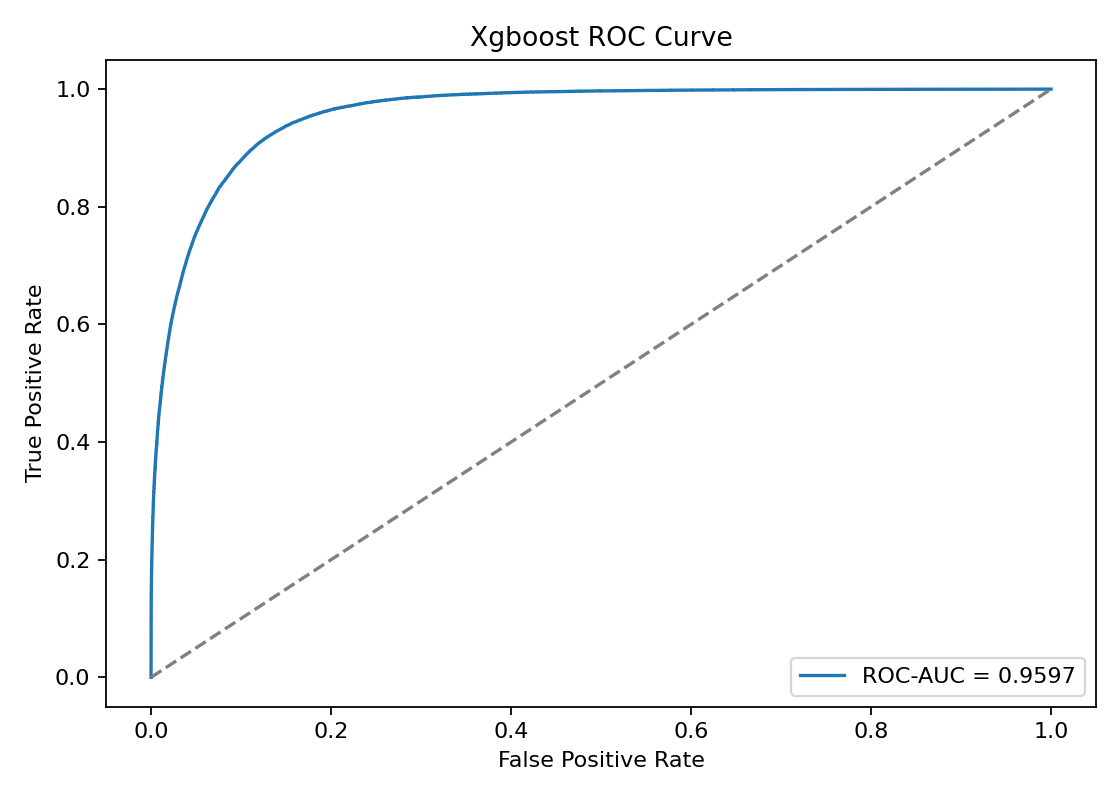

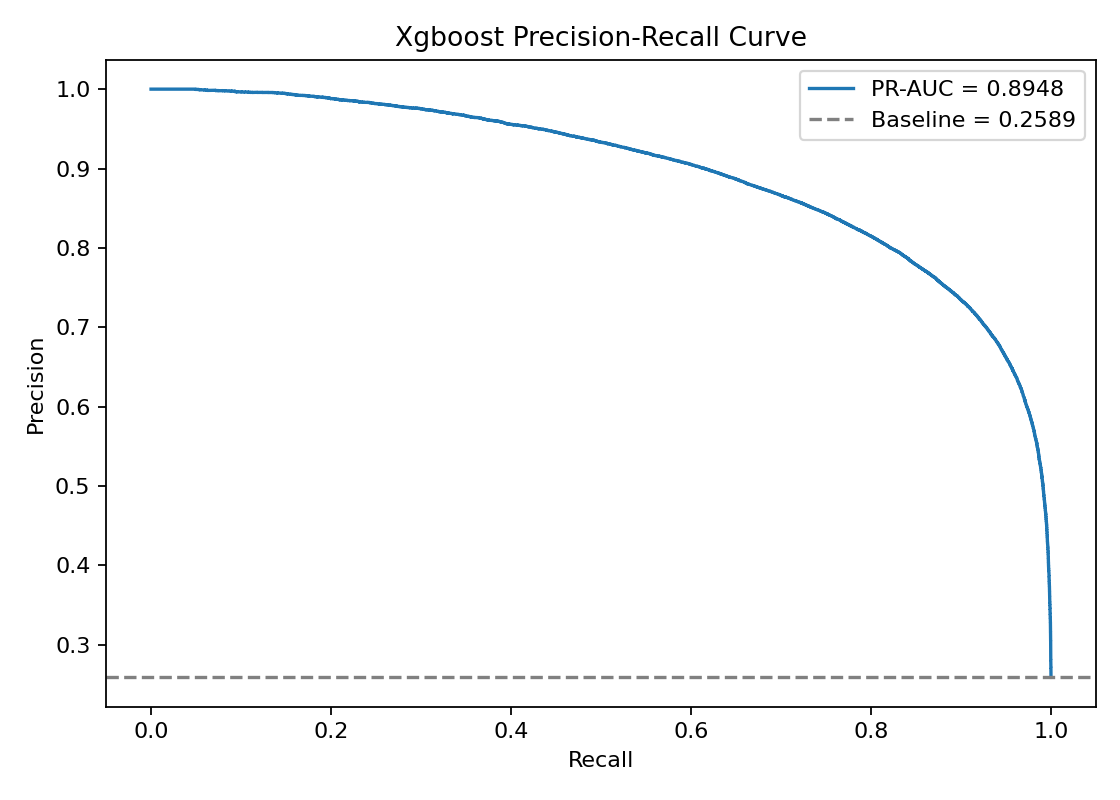

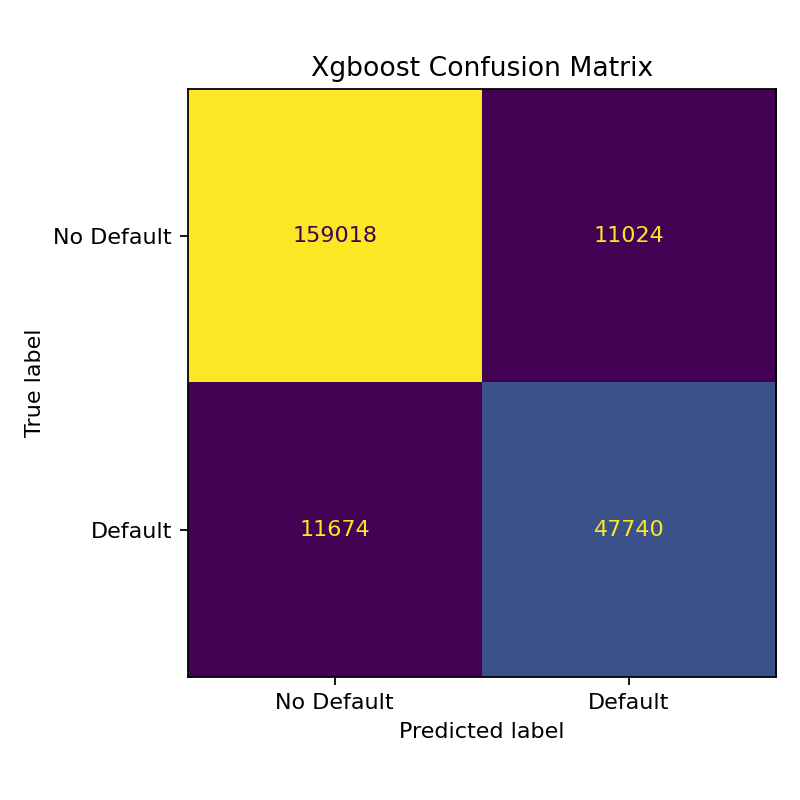

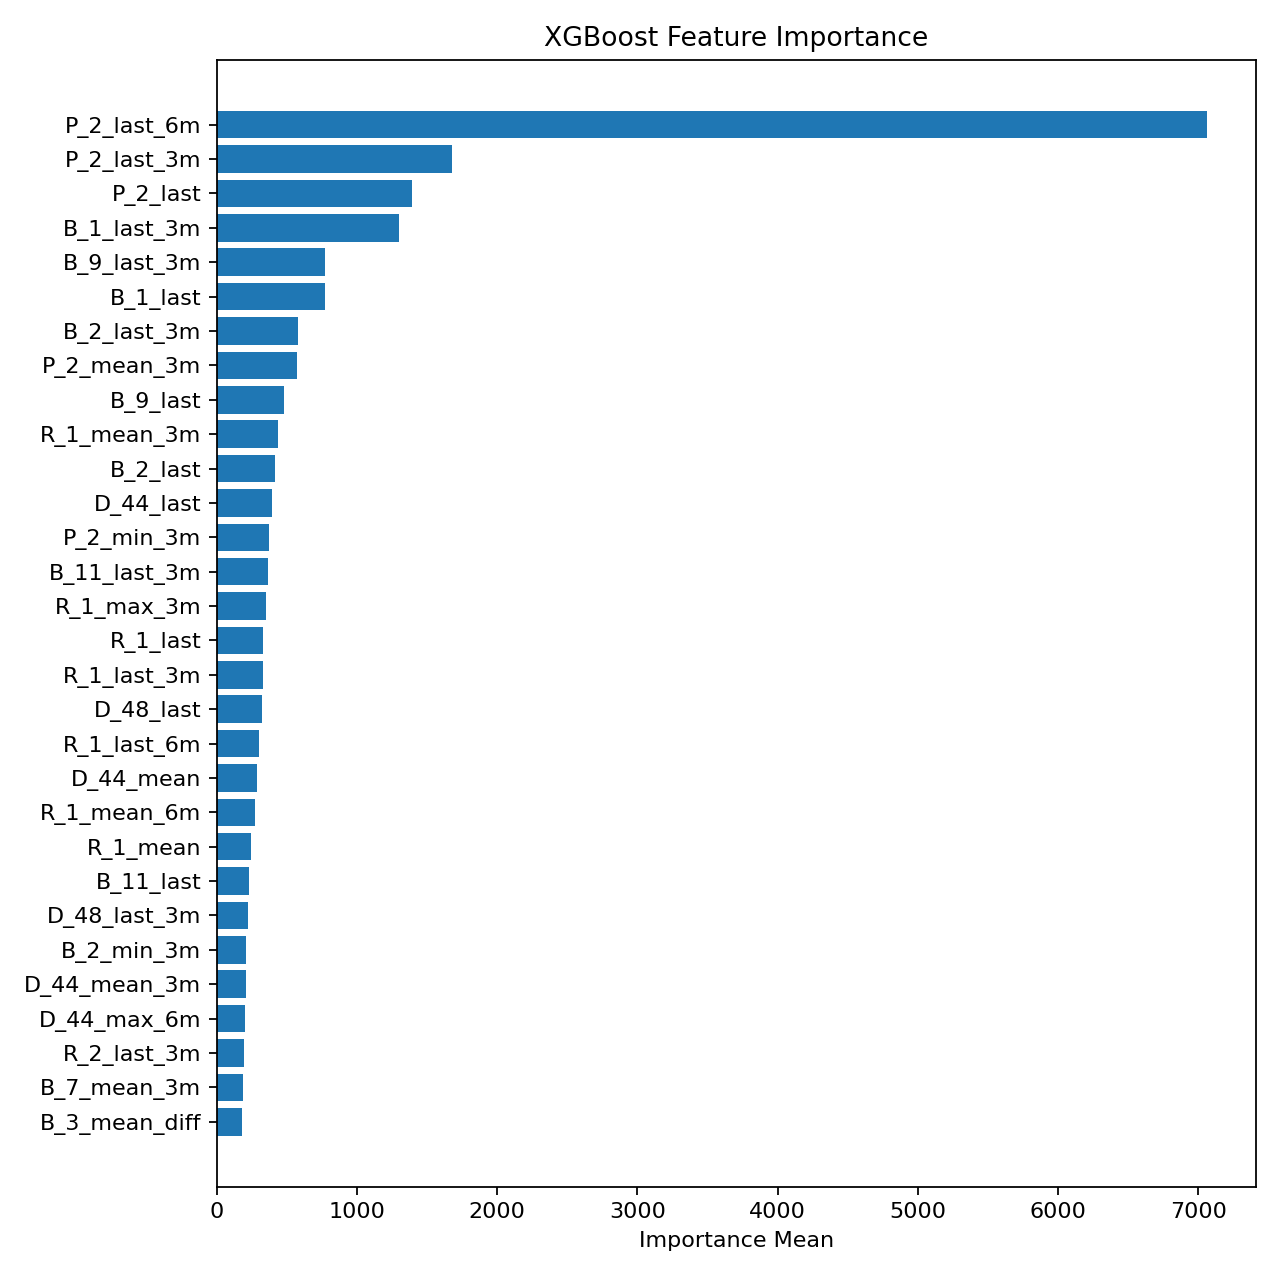

In [3]:
result = train_cv(X, y, customer_ids=df["customer_ID"])
save_cv_artifacts(result)

metrics = result["metrics"]
metric_cols = [
    "model", "n_rows", "n_features", "roc_auc", "pr_auc",
    "precision", "recall", "f1", "threshold",
    "training_time_seconds", "inference_time_seconds", "total_time_seconds",
]
display(pd.DataFrame([metrics]).reindex(columns=metric_cols))

display(result["feature_importance"].head(20))

for filename in [
    "xgboost_roc_curve.png",
    "xgboost_pr_curve.png",
    "xgboost_confusion_matrix.png",
    "xgboost_feature_importance.png",
]:
    display(Image(filename=str(PLOTS_DIR / filename)))
